In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import holidays
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, make_scorer

## Data Import & Inspection

In [3]:
# define the data that we want to use

start_date = "2025-02-01 00:00:00"
end_date  = "2026-02-01 00:00:00"
train_date = "2026-01-01"


In [10]:
#encoded_netgen is already preprocessed using another notebook
weather_df=pd.read_csv("../../raw_data/weather_avg.csv")
generation_df = pd.read_csv("../../raw_data/encoded_netgen.csv")
oilgas_df = pd.read_csv("../../raw_data/oil_gas_prices.csv")
load_df = pd.read_csv("../../raw_data/load_data.csv")
target_df = pd.read_csv("../../raw_data/combined_energy_price_clean.csv", sep='\t')


# electricity price is also preprocessed úsing another notebook
# we just need to remove sequence 1
# sequence 1 is the more correct price to predict
# we decided to use sequence 2 because 15min interval goes further back
target_df = target_df[target_df["Sequence"] != 1]

# oil gas price is daily, also some days are missing due to holiday and weekends
# lets fill missing day values with the price the day before
# then we make it 15-minutes interval but having the same price the whole day

oilgas_df["period"] = pd.to_datetime(oilgas_df["period"])
oilgas_df = oilgas_df.set_index("period").sort_index()

# Create full daily date range
full_range = pd.date_range(start=oilgas_df.index.min(), end=oilgas_df.index.max(), freq="D")

# Reindex to include missing days (weekends/holidays)
oilgas_df = oilgas_df.reindex(full_range)

# Fill missing values with previous day's price
oilgas_df = oilgas_df.ffill()

# Upsample to 15-minute frequency
oilgas_df = oilgas_df.resample("15min").ffill()

oilgas_df = oilgas_df.reset_index()
oilgas_df = oilgas_df.rename(columns={'index': 'DateTime(UTC)'})

# load is raw data obtained from API (Javier)
# the time is in berlin, we will convert it to utc
# we will avaerage out duplicated timesptes
# there are missing values due to end of March

load_df = load_df.rename(columns={"Unnamed: 0": "DateTime(UTC)"})

# Step 1: ensure string and remove last 6 chars
load_df["DateTime(UTC)"] = load_df["DateTime(UTC)"].astype(str).str[:-6]

# Step 2: convert to datetime
load_df["DateTime(UTC)"] = pd.to_datetime(load_df["DateTime(UTC)"], errors="coerce")

# Step 3: subtract 1 hour
# convert to utc
load_df["DateTime(UTC)"] = load_df["DateTime(UTC)"] - pd.Timedelta(hours=1)

# There are duplicated timestep with different valaues, lets take the average for those timesteps
load_df = (
    load_df
    .groupby('DateTime(UTC)', as_index=False)['load']
    .mean()
)

load_df = load_df.set_index('DateTime(UTC)').sort_index()
full_range = pd.date_range(
    start=load_df.index.min(),
    end=load_df.index.max(),
    freq='15min'
)

load_df = load_df.reindex(full_range).ffill()
load_df = load_df.reset_index().rename(columns={'index': 'DateTime(UTC)'})

/var/folders/sj/pc75w_ds6w72_p6qqgqy9m980000gn/T/ipykernel_95141/2526917947.py:6: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  target_df = pd.read_csv("../../raw_data/combined_energy_price_clean.csv", sep='\t')


In [11]:
oilgas_df.head()

,DateTime(UTC),WTI_Oil,Brent_Oil,Natural_Gas
0,2006-05-16 00:00:00,69.4,NaN,NaN
1,2006-05-16 00:15:00,69.4,NaN,NaN
2,2006-05-16 00:30:00,69.4,NaN,NaN
3,2006-05-16 00:45:00,69.4,NaN,NaN
4,2006-05-16 01:00:00,69.4,NaN,NaN


In [12]:
# Merge and truncate

merged_df = generation_df.merge(
    target_df[["DateTime(UTC)", "Price[Currency/MWh]"]],
    on="DateTime(UTC)",
    how="left"
)

oilgas_df['DateTime(UTC)'] = oilgas_df['DateTime(UTC)'].astype(str)

merged_df = merged_df.merge(
    oilgas_df[["DateTime(UTC)", "WTI_Oil", "Brent_Oil", "Natural_Gas"]],
    on="DateTime(UTC)",
    how="left"
)

load_df['DateTime(UTC)'] = load_df['DateTime(UTC)'].astype(str)

merged_df = merged_df.merge(
    load_df[["DateTime(UTC)", "load"]],
    on="DateTime(UTC)",
    how="left"
)

merged_df["DateTime(UTC)"] = pd.to_datetime(merged_df["DateTime(UTC)"])
merged_df = merged_df.sort_values("DateTime(UTC)")
merged_df = merged_df.set_index("DateTime(UTC)")
merged_df = merged_df.loc[start_date:end_date]
merged_df = merged_df.reset_index()

In [13]:
def merge_time_series_with_weather(
    main_df,
    weather_df,
    datetime_col="DateTime(UTC)",
    strategy="ffill"  # "ffill" or "interpolate"
    ):
        # -------------------------
    # 1. Convert datetime
    # -------------------------
    main_df = main_df.copy()
    weather_df = weather_df.copy()

    main_df[datetime_col] = pd.to_datetime(main_df[datetime_col])
    weather_df[datetime_col] = pd.to_datetime(weather_df[datetime_col])

    # -------------------------
    # 2. Set index
    # -------------------------
    main_df = main_df.set_index(datetime_col).sort_index()
    weather_df = weather_df.set_index(datetime_col).sort_index()

    # -------------------------
    # 3. Reindex weather to match main timeline
    # -------------------------
    weather_aligned = weather_df.reindex(main_df.index)

    # -------------------------
    # 4. Imputation strategy
    # -------------------------
    if strategy == "ffill":
        weather_aligned = weather_aligned.ffill()

    elif strategy == "interpolate":
        weather_aligned = weather_aligned.interpolate(method="time")

    else:
        raise ValueError("strategy must be either 'ffill' or 'interpolate'")

    # -------------------------
    # 5. Merge
    # -------------------------
    merged = main_df.join(weather_aligned)

    return merged.reset_index()

In [14]:
model_df = merge_time_series_with_weather(
    merged_df,
    weather_df,
    strategy="ffill"
)

## Feature manipulation

In [15]:
# ---- Basic time features ----
model_df["day_of_week"] = model_df["DateTime(UTC)"].dt.dayofweek
model_df["day_of_year"] = model_df["DateTime(UTC)"].dt.dayofyear
model_df["month"] = model_df["DateTime(UTC)"].dt.month
model_df["year"] = model_df["DateTime(UTC)"].dt.year

# ---- Hour + quarter-hour ----
model_df["hour"] = model_df["DateTime(UTC)"].dt.hour

# quarter of hour: 0,1,2,3
model_df["quarter_hour"] = model_df["DateTime(UTC)"].dt.minute // 15

# ---- German public holidays ----
years = model_df["year"].unique()
de_holidays = holidays.Germany(years=years)

model_df["is_holiday"] = model_df["DateTime(UTC)"].dt.floor("D").isin(de_holidays)

# ---- Bridge day (Brückentag) ----
# A bridge day is typically:
# - Monday before a Tuesday holiday
# - Friday after a Thursday holiday

model_df["date"] = model_df["DateTime(UTC)"].dt.date

holidays_set = set(de_holidays)

def is_bridge_day(date):
    weekday = date.weekday()

    # Monday before Tuesday holiday
    if weekday == 0 and (date + pd.Timedelta(days=1)) in holidays_set:
        return 1

    # Friday after Thursday holiday
    if weekday == 4 and (date - pd.Timedelta(days=1)) in holidays_set:
        return 1

    return 0

model_df["is_bridge_day"] = model_df["date"].apply(is_bridge_day)

# convert holiday boolean to int
model_df["is_holiday"] = model_df["is_holiday"].astype(int)

/var/folders/sj/pc75w_ds6w72_p6qqgqy9m980000gn/T/ipykernel_95141/705250505.py:17: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  model_df["is_holiday"] = model_df["DateTime(UTC)"].dt.floor("D").isin(de_holidays)


In [16]:
# remove the ordinal features and cyclical encode them
def cyclical_encode(df, col, max_val, offset=0, drop=True):
    sin_col = f"{col}_sin"
    cos_col = f"{col}_cos"

    df[sin_col] = np.sin(2 * np.pi * (df[col] - offset) / max_val)
    df[cos_col] = np.cos(2 * np.pi * (df[col] - offset) / max_val)

    if drop:
        df = df.drop(columns=[col])

    return df

# Apply to your dataframe
model_df = cyclical_encode(model_df, "quarter_hour", 4)
model_df = cyclical_encode(model_df, "hour", 24)
model_df = cyclical_encode(model_df, "day_of_week", 7)
model_df = cyclical_encode(model_df, "day_of_year", 365, offset=1)
model_df = cyclical_encode(model_df, "month", 12, offset=1)

In [17]:
# Target
# Rolling mean
model_df["price_roll_mean_24"] = model_df["Price[Currency/MWh]"].rolling(24).mean()
model_df["price_roll_mean_96"] = model_df["Price[Currency/MWh]"].rolling(96).mean()
model_df["price_roll_mean_672"] = model_df["Price[Currency/MWh]"].rolling(672).mean()

# Rolling std
model_df["price_roll_std_4"] = model_df["Price[Currency/MWh]"].rolling(4).std()
model_df["price_roll_std_24"] = model_df["Price[Currency/MWh]"].rolling(24).std()
model_df["price_roll_std_96"] = model_df["Price[Currency/MWh]"].rolling(96).std()

model_df["price_lag_1"] = model_df["Price[Currency/MWh]"].shift(1)
model_df["price_lag_4"] = model_df["Price[Currency/MWh]"].shift(4)
model_df["price_lag_12"] = model_df["Price[Currency/MWh]"].shift(12)   # 3 hours
model_df["price_lag_24"] = model_df["Price[Currency/MWh]"].shift(24)   # 6 hours
model_df["price_lag_96"] = model_df["Price[Currency/MWh]"].shift(96)   # 1 day
model_df["price_lag_672"] = model_df["Price[Currency/MWh]"].shift(672) # 1 week

In [18]:
# generation

model_df["variable_roll_mean_4"] = model_df["variable"].rolling(4).mean()
model_df["variable_roll_mean_24"] = model_df["variable"].rolling(24).mean()
model_df["variable_roll_mean_96"] = model_df["variable"].rolling(96).mean()
model_df["variable_roll_mean_672"] = model_df["variable"].rolling(672).mean()

# Rolling std
model_df["variable_roll_std_4"] = model_df["variable"].rolling(4).std()
model_df["variable_roll_std_24"] = model_df["variable"].rolling(24).std()
model_df["variable_roll_std_96"] = model_df["variable"].rolling(96).std()

model_df["variable_lag_1"] = model_df["variable"].shift(1)
model_df["variable_lag_4"] = model_df["variable"].shift(4)
model_df["variable_lag_12"] = model_df["variable"].shift(12)   # 3 hours
model_df["variable_lag_24"] = model_df["variable"].shift(24)   # 6 hours
model_df["variable_lag_96"] = model_df["variable"].shift(96)   # 1 day
model_df["variable_lag_672"] = model_df["variable"].shift(672) # 1 week

In [19]:
# let's generate lad and rolling for oil and gas price as well
# only 672 and 1344 rolling are used because oil and gas prices are daily and dont varies much short term
# tested 672 and 1344 rolling are better than just 672 rolling
# so now we have to truncate more data

model_df["wti_roll_mean_672"] = model_df["WTI_Oil"].rolling(672).mean()
model_df["brent_roll_mean_672"] = model_df["Brent_Oil"].rolling(672).mean()
model_df["gas_roll_mean_672"] = model_df["Natural_Gas"].rolling(672).mean()
model_df["wti_roll_mean_1344"] = model_df["WTI_Oil"].rolling(1344).mean()
model_df["brent_roll_mean_1344"] = model_df["Brent_Oil"].rolling(1344).mean()
model_df["gas_roll_mean_1344"] = model_df["Natural_Gas"].rolling(1344).mean()

# Rolling std
model_df["wti_roll_std_672"] = model_df["WTI_Oil"].rolling(672).std()
model_df["brent_roll_std_672"] = model_df["Brent_Oil"].rolling(672).std()
model_df["gas_roll_std_672"] = model_df["Natural_Gas"].rolling(672).std()
model_df["wti_roll_std_1344"] = model_df["WTI_Oil"].rolling(1344).std()
model_df["brent_roll_std_1344"] = model_df["Brent_Oil"].rolling(1344).std()
model_df["gas_roll_std_1344"] = model_df["Natural_Gas"].rolling(1344).std()

# price lag
model_df["wti_lag_672"] = model_df["WTI_Oil"].shift(672)
model_df["brent_lag_672"] = model_df["Brent_Oil"].shift(672)
model_df["gas_lag_672"] = model_df["Natural_Gas"].shift(672)
model_df["wti_lag_1344"] = model_df["WTI_Oil"].shift(1344)
model_df["brent_lag_1344"] = model_df["Brent_Oil"].shift(1344)
model_df["gas_lag_1344"] = model_df["Natural_Gas"].shift(1344)

In [20]:
model_df["target_288"] = model_df["Price[Currency/MWh]"].shift(-288)
# also add column for known feature of 288 time steps later
model_df['is_holiday_288'] = model_df['is_holiday'].shift(-288)
model_df['is_bridge_day_288'] = model_df['is_bridge_day'].shift(-288)
model_df = model_df.dropna().reset_index(drop=True)

In [21]:
model_df['temperature_c_288'] = model_df['temperature_c'].shift(-96)
model_df['humidity_percent_288'] = model_df['humidity_percent'].shift(-96)
model_df['cloud_cover_percent_288'] = model_df['cloud_cover_percent'].shift(-96)
model_df['shortwave_radiation_wm2_288'] = model_df['shortwave_radiation_wm2'].shift(-96)
model_df['temperature_c_288'] = model_df['temperature_c'].shift(-192)
model_df['humidity_percent_288'] = model_df['humidity_percent'].shift(-192)
model_df['cloud_cover_percent_288'] = model_df['cloud_cover_percent'].shift(-192)
model_df['shortwave_radiation_wm2_288'] = model_df['shortwave_radiation_wm2'].shift(-192)
model_df['temperature_c_288'] = model_df['temperature_c'].shift(-288)
model_df['humidity_percent_288'] = model_df['humidity_percent'].shift(-288)
model_df['cloud_cover_percent_288'] = model_df['cloud_cover_percent'].shift(-288)
model_df['shortwave_radiation_wm2_288'] = model_df['shortwave_radiation_wm2'].shift(-288)
model_df = model_df.dropna().reset_index(drop=True)

### Add-ons

In [22]:
df = model_df.copy()
# total generation (adjust if needed)
df["total_generation"] = df["stable"] + df["variable"] + df["other"] + df["other_renewable"]

# residual load (VERY important)
df["residual_load"] = df["load"] - df["variable"]

# generation shares
df["share_variable"] = df["variable"] / df["total_generation"]
df["share_stable"] = df["stable"] / df["total_generation"]
df["share_other"] = df["other"] / df["total_generation"]

# avoid division issues
df.replace([np.inf, -np.inf], np.nan, inplace=True)


# =========================================================
# 2) INTERACTION FEATURES
# =========================================================

df["temp_x_load"] = df["temperature_c"] * df["load"]
df["cloud_x_radiation"] = df["cloud_cover_percent"] * df["shortwave_radiation_wm2"]
df["gas_x_residual_load"] = df["Natural_Gas"] * df["residual_load"]


# =========================================================
# 3) IMPROVED LAG STRUCTURE
# =========================================================

# 15-min data → 96 = 1 day
df["price_lag_192"] = df["Price[Currency/MWh]"].shift(192)   # 2 days
df["price_lag_288"] = df["Price[Currency/MWh]"].shift(288)   # 3 days

# weekly pattern refinement (same hour neighborhood)
df["price_weekly_mean"] = (
    df["Price[Currency/MWh]"].shift(672) +   # 7 days
    df["Price[Currency/MWh]"].shift(672 + 96) +
    df["Price[Currency/MWh]"].shift(672 - 96)
) / 3

# momentum features
df["price_momentum_1_4"] = df["price_lag_1"] - df["price_lag_4"]
df["price_momentum_4_12"] = df["price_lag_4"] - df["price_lag_12"]


# =========================================================
# 4) ROLLING + VOLATILITY / REGIME FEATURES
# =========================================================

# exponential weighted mean (faster reaction)
df["price_ewm_24"] = df["Price[Currency/MWh]"].ewm(span=24).mean()
df["price_ewm_96"] = df["Price[Currency/MWh]"].ewm(span=96).mean()

# rolling min / max
df["price_roll_min_96"] = df["Price[Currency/MWh]"].rolling(96).min()
df["price_roll_max_96"] = df["Price[Currency/MWh]"].rolling(96).max()

# volatility regime
df["price_volatility_96"] = df["Price[Currency/MWh]"].rolling(96).std()

# high volatility flag
vol_threshold = df["price_volatility_96"].quantile(0.75)
df["high_volatility_flag"] = (df["price_volatility_96"] > vol_threshold).astype(int)

# price regime (spike detection)
rolling_q95 = df["Price[Currency/MWh]"].rolling(96).quantile(0.95)
df["price_spike_flag"] = (df["Price[Currency/MWh]"] > rolling_q95).astype(int)

# distance from mean
df["price_vs_mean"] = df["Price[Currency/MWh]"] - df["price_roll_mean_96"]


# =========================================================
# 5) FORECAST-ALIGNED FEATURES (STRUCTURE)
# =========================================================

# You already have *_288 → extend pattern

# +1 day (96)
df["temperature_c_96"] = df["temperature_c"].shift(-96)
df["load_96"] = df["load"].shift(-96)

# +2 days (192)
df["temperature_c_192"] = df["temperature_c"].shift(-192)
df["load_192"] = df["load"].shift(-192)

# NOTE:
# Only keep these if they represent REAL forecasts in production.
# Otherwise, they introduce leakage.


# =========================================================
# CLEANUP
# =========================================================

df = df.dropna().reset_index(drop=True)

# assign back
model_df = df

In [59]:
print(model_df.columns.to_list())

['DateTime(UTC)', 'other', 'other_renewable', 'stable', 'variable', 'Price[Currency/MWh]', 'WTI_Oil', 'Brent_Oil', 'Natural_Gas', 'load', 'temperature_c', 'humidity_percent', 'cloud_cover_percent', 'shortwave_radiation_wm2', 'year', 'is_holiday', 'date', 'is_bridge_day', 'quarter_hour_sin', 'quarter_hour_cos', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'day_of_year_sin', 'day_of_year_cos', 'month_sin', 'month_cos', 'price_roll_mean_24', 'price_roll_mean_96', 'price_roll_mean_672', 'price_roll_std_4', 'price_roll_std_24', 'price_roll_std_96', 'price_lag_1', 'price_lag_4', 'price_lag_12', 'price_lag_24', 'price_lag_96', 'price_lag_672', 'variable_roll_mean_4', 'variable_roll_mean_24', 'variable_roll_mean_96', 'variable_roll_mean_672', 'variable_roll_std_4', 'variable_roll_std_24', 'variable_roll_std_96', 'variable_lag_1', 'variable_lag_4', 'variable_lag_12', 'variable_lag_24', 'variable_lag_96', 'variable_lag_672', 'wti_roll_mean_672', 'brent_roll_mean_672', 'gas_roll_

## Modelling

In [24]:
start_date = pd.to_datetime(start_date, format="%Y-%m-%d %H:%M:%S")
end_date = pd.to_datetime(end_date, format="%Y-%m-%d %H:%M:%S")

In [39]:
model_df["DateTime(UTC)"] =  pd.to_datetime(model_df["DateTime(UTC)"], format="%Y-%m-%d %H:%M:%S")

In [26]:
data_12m = model_df[(model_df["DateTime(UTC)"] >= start_date) & (model_df["DateTime(UTC)"] <= end_date)]

In [31]:
len(data_12m)

32161

In [29]:
data_12m["DateTime(UTC)"].min(), data_12m["DateTime(UTC)"].max()

(Timestamp('2025-02-23 00:00:00'), Timestamp('2026-01-24 00:00:00'))

In [32]:
data_12m.columns

Index(['DateTime(UTC)', 'other', 'other_renewable', 'stable', 'variable',
       'Price[Currency/MWh]', 'WTI_Oil', 'Brent_Oil', 'Natural_Gas', 'load',
       ...
       'price_roll_min_96', 'price_roll_max_96', 'price_volatility_96',
       'high_volatility_flag', 'price_spike_flag', 'price_vs_mean',
       'temperature_c_96', 'load_96', 'temperature_c_192', 'load_192'],
      dtype='object', length=103)

In [ ]:
#for running the VM, download data here
#data_12m.to_csv("grid_search.csv")

## Grid search

In [33]:
# ---------------------------
# 1. Prepare data
# ---------------------------


# Define target (3 days ahead = 288 steps)
target = 'target_288'

# Drop non-feature columns
drop_cols = ['DateTime(UTC)',
             'Price[Currency/MWh]',
             target,
             'date']
X = data_12m.drop(columns=drop_cols)
y = data_12m[target]

# ---------------------------
# 2. Time series split
# ---------------------------

tscv = TimeSeriesSplit(n_splits=5)

# ---------------------------
# 3. Define model
# ---------------------------

model = XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',   # fast for large datasets
    random_state=42
)

# ---------------------------
# 4. Hyperparameter grid
# ---------------------------

param_grid = {
    'n_estimators': [300, 600, 1000],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10]
}

# ---------------------------
# 5. Scoring metric
# ---------------------------

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# ---------------------------
# 6. Grid Search
# ---------------------------

random_search = RandomizedSearchCV(
    model,
    param_distributions=param_grid,
    n_iter=100,  # try 50–100 first
    scoring=mae_scorer,
    cv=tscv,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X, y)

# ---------------------------
# 7. Results
# ---------------------------

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest MAE:")
print(-random_search.best_score_)

# Best model
best_model = random_search.best_estimator_

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END colsample_bytree=0.9, gamma=0, learning_rate=0.01, max_depth=4, n_estimators=1000, reg_alpha=0.1, reg_lambda=10, subsample=1.0; total time=   4.2s
[CV] END colsample_bytree=0.9, gamma=0, learning_rate=0.01, max_depth=4, n_estimators=1000, reg_alpha=0.1, reg_lambda=10, subsample=1.0; total time=   5.3s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.1, max_depth=8, n_estimators=300, reg_alpha=1, reg_lambda=5, subsample=0.9; total time=   5.9s
[CV] END colsample_bytree=0.9, gamma=0, learning_rate=0.01, max_depth=4, n_estimators=1000, reg_alpha=0.1, reg_lambda=10, subsample=1.0; total time=   6.4s
[CV] END colsample_bytree=0.9, gamma=0, learning_rate=0.01, max_depth=4, n_estimators=1000, reg_alpha=0.1, reg_lambda=10, subsample=1.0; total time=   7.5s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.1, max_depth=8, n_estimators=300, reg_alpha=1, reg_lambda=5, subsample=0.9; total time=   8.6s
[CV] EN

/Users/laurenzpfleiderer/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.05, max_depth=10, n_estimators=1000, reg_alpha=0.1, reg_lambda=10, subsample=1.0; total time=  26.6s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.01, max_depth=10, n_estimators=600, reg_alpha=0.1, reg_lambda=1, subsample=1.0; total time= 1.1min
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.01, max_depth=10, n_estimators=600, reg_alpha=0.1, reg_lambda=1, subsample=1.0; total time= 1.2min
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.01, max_depth=8, n_estimators=1000, reg_alpha=0.1, reg_lambda=10, subsample=0.7; total time=  23.3s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.05, max_depth=10, n_estimators=1000, reg_alpha=0.1, reg_lambda=10, subsample=1.0; total time=  38.9s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.01, max_depth=8, n_estimators=1000, reg_alpha=0.1, reg_lambda=10, subsample=0.7; total time=  29.7s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=

In [ ]:
# ---------------------------
# 1. Prepare data
# ---------------------------

df = data_12m.copy()
df = df.sort_values("DateTime(UTC)")

# Target
y = df["target_288"]

# Drop non-feature columns
X = df.drop(columns=[
    "target_288",
    "Price[Currency/MWh]",   # avoid leakage if this is your actual target base
    "DateTime(UTC)",
    "date"
], errors="ignore")

# ---------------------------
# 2. Time series CV
# ---------------------------

tscv = TimeSeriesSplit(n_splits=5)

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# ---------------------------
# 3. Base model
# ---------------------------

model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

# ---------------------------
# 4. Focused hyperparameter grid
# (refined around your best model)
# ---------------------------

param_grid = {
    # tree complexity (VERY important for MAE reduction)
    "max_depth": [5, 6, 7, 8, 9, 10],

    # prevents overfitting in deep trees
    "min_child_weight": [1, 3, 5, 10, 15, 20],

    # learning rate (lower = better generalization)
    "learning_rate": [0.003, 0.005, 0.008, 0.01, 0.015, 0.02],

    # number of trees (use early stopping instead of tuning aggressively)
    "n_estimators": [2000, 3000, 4000],

    # row sampling (stabilizes noisy energy data)
    "subsample": [1.0],

    # feature sampling (important with 100+ features)
    "colsample_bytree": [0.7],

    # regularization (critical for MAE improvement)
    "reg_alpha": [0.1, 0.5],
    "reg_lambda": [5, 10],
}

# ---------------------------
# 5. Grid Search with early stopping
# ---------------------------

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=mae_scorer,
    cv=tscv,
    verbose=2,
    n_jobs=-1
)

# Fit (IMPORTANT: early stopping inside each fold)
grid_search.fit(
    X,
    y,
    eval_set=[(X, y)],  # placeholder; CV handles splitting
    verbose=False
)

# ---------------------------
# 6. Results
# ---------------------------

print("Best MAE (negated):", grid_search.best_score_)
print("Best parameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 2592 candidates, totalling 12960 fits
[CV] END colsample_bytree=0.7, learning_rate=0.003, max_depth=5, min_child_weight=1, n_estimators=2000, reg_alpha=0.1, reg_lambda=10, subsample=1.0; total time=  25.6s
[CV] END colsample_bytree=0.7, learning_rate=0.003, max_depth=5, min_child_weight=1, n_estimators=2000, reg_alpha=0.1, reg_lambda=5, subsample=1.0; total time=  25.7s
[CV] END colsample_bytree=0.7, learning_rate=0.003, max_depth=5, min_child_weight=1, n_estimators=2000, reg_alpha=0.1, reg_lambda=5, subsample=1.0; total time=  28.3s
[CV] END colsample_bytree=0.7, learning_rate=0.003, max_depth=5, min_child_weight=1, n_estimators=2000, reg_alpha=0.1, reg_lambda=10, subsample=1.0; total time=  28.6s
[CV] END colsample_bytree=0.7, learning_rate=0.003, max_depth=5, min_child_weight=1, n_estimators=2000, reg_alpha=0.1, reg_lambda=5, subsample=1.0; total time=  30.6s
[CV] END colsample_bytree=0.7, learning_rate=0.003, max_depth=5, min_child_weight=1, n_estimators

/Users/laurenzpfleiderer/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END colsample_bytree=0.7, learning_rate=0.003, max_depth=8, min_child_weight=1, n_estimators=4000, reg_alpha=0.1, reg_lambda=10, subsample=1.0; total time= 1.9min
[CV] END colsample_bytree=0.7, learning_rate=0.003, max_depth=8, min_child_weight=1, n_estimators=4000, reg_alpha=0.5, reg_lambda=5, subsample=1.0; total time= 1.4min
[CV] END colsample_bytree=0.7, learning_rate=0.003, max_depth=8, min_child_weight=1, n_estimators=4000, reg_alpha=0.1, reg_lambda=5, subsample=1.0; total time= 2.4min
[CV] END colsample_bytree=0.7, learning_rate=0.003, max_depth=8, min_child_weight=1, n_estimators=4000, reg_alpha=0.1, reg_lambda=10, subsample=1.0; total time= 2.1min
[CV] END colsample_bytree=0.7, learning_rate=0.003, max_depth=8, min_child_weight=1, n_estimators=4000, reg_alpha=0.5, reg_lambda=5, subsample=1.0; total time= 1.7min
[CV] END colsample_bytree=0.7, learning_rate=0.003, max_depth=8, min_child_weight=1, n_estimators=4000, reg_alpha=0.1, reg_lambda=10, subsample=1.0; total time= 2.

## Fit and display results

In [35]:
# ---------------------------
# 2. Define target + features
# ---------------------------

# Define target (3 days ahead = 288 steps)
target = 'target_288'

# Drop non-feature columns
drop_cols = ['DateTime(UTC)',
             'Price[Currency/MWh]',
             target,
             'date']
X = data_12m.drop(columns=drop_cols)
y = data_12m[target]

# ---------------------------
# 3. Train / Test split
# ---------------------------

# Last 3 days = 288 timesteps
forecast_horizon = 288

X_train = X.iloc[:-forecast_horizon]
y_train = y.iloc[:-forecast_horizon]

X_test = X.iloc[-forecast_horizon:]
y_test = y.iloc[-forecast_horizon:]

# ---------------------------
# 4. Train final model
# ---------------------------

best_params = random_search.best_params_

model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    **best_params
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1.0
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [36]:
y_pred = model.predict(X_test)

In [37]:
results = pd.DataFrame({
    "DateTime": data_12m['DateTime(UTC)'].iloc[-forecast_horizon:],
    "Actual_Price": data_12m['Price[Currency/MWh]'].iloc[-forecast_horizon:],
    "Predicted_Price": y_pred
})
results["DateTime_shifted"] = results["DateTime"] - pd.Timedelta(days=3)

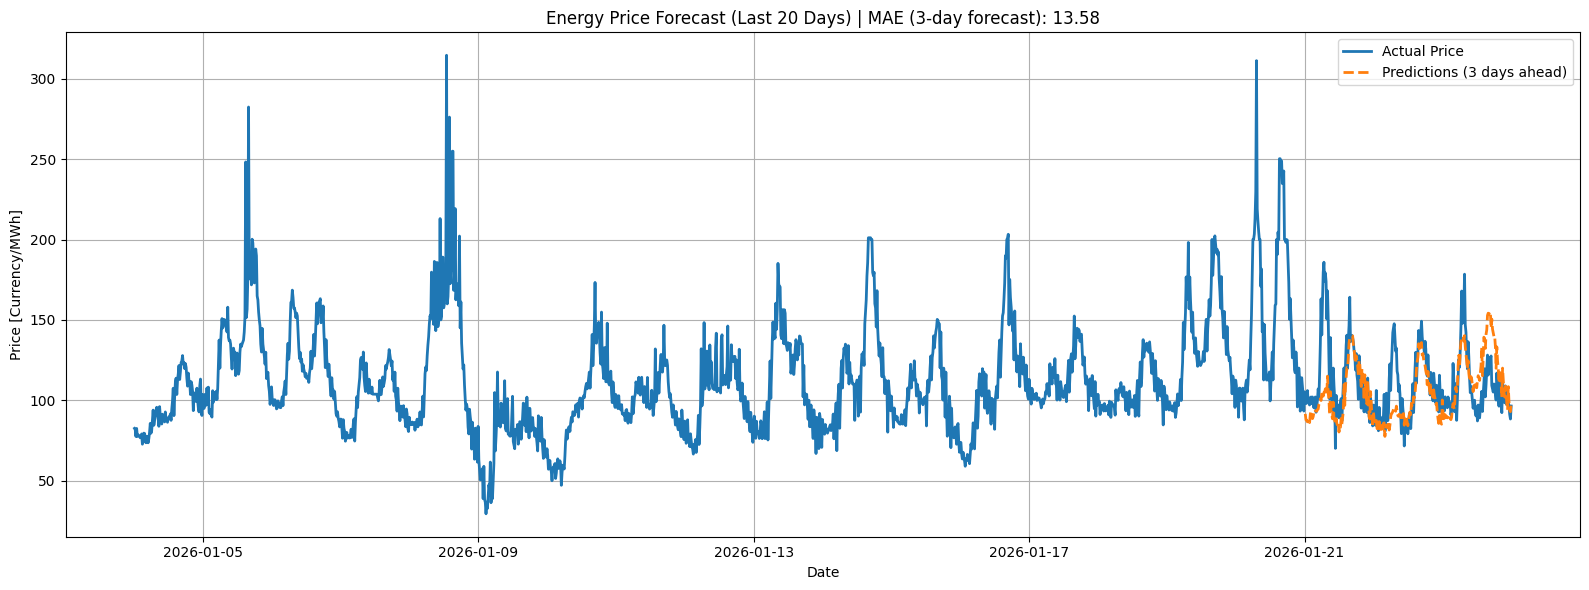

In [38]:
# ---------------------------
# Compute MAE
# ---------------------------

mae = mean_absolute_error(results["Actual_Price"], results["Predicted_Price"])

# ---------------------------
# 7. Plot last 20 days
# ---------------------------

# 20 days = 20 * 96 timesteps
plot_horizon = 20 * 96

plot_data = data_12m.iloc[-plot_horizon:].copy()

plt.figure(figsize=(16, 6))

# Actual prices
plt.plot(
    plot_data['DateTime(UTC)'],
    plot_data['Price[Currency/MWh]'],
    label='Actual Price',
    linewidth=2
)

# Predictions (only last 3 days)
plt.plot(
    results['DateTime'],
    results['Predicted_Price'],
    label='Predictions (3 days ahead)',
    linestyle='--',
    linewidth=2
)

# Predictions (shifted)
# plt.plot(
#     results['DateTime_shifted'],
#     results['Predicted_Price'],
#     label='Predictions (made 3 days earlier)',
#     linestyle='--',
#     linewidth=2
# )

plt.title(f'Energy Price Forecast (Last 20 Days) | MAE (3-day forecast): {mae:.2f}')
plt.xlabel('Date')
plt.ylabel('Price [Currency/MWh]')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## validate forecast with different time steps

### 1. 15th January 2026

In [49]:
start_date = pd.to_datetime("2025-02-01 00:00:00", format="%Y-%m-%d %H:%M:%S")
end_date = pd.to_datetime("2026-01-15 00:00:00", format="%Y-%m-%d %H:%M:%S")
model_df["DateTime(UTC)"] =  pd.to_datetime(model_df["DateTime(UTC)"], format="%Y-%m-%d %H:%M:%S")
data_12m = model_df[(model_df["DateTime(UTC)"] >= start_date) & (model_df["DateTime(UTC)"] <= end_date)]
len(data_12m)


31297

In [50]:
data_12m["DateTime(UTC)"].min(), data_12m["DateTime(UTC)"].max()

(Timestamp('2025-02-23 00:00:00'), Timestamp('2026-01-15 00:00:00'))

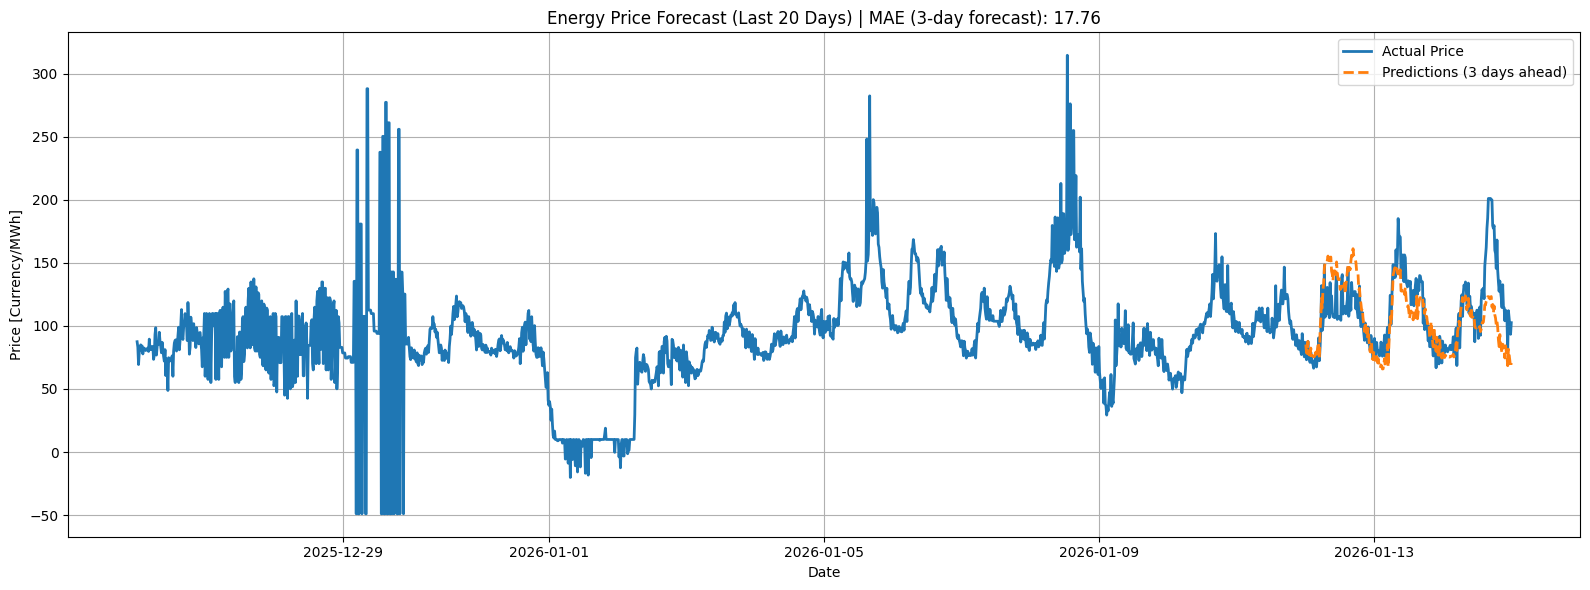

In [52]:
# ---------------------------
# 2. Define target + features
# ---------------------------

# Define target (3 days ahead = 288 steps)
target = 'target_288'

# Drop non-feature columns
drop_cols = ['DateTime(UTC)',
             'Price[Currency/MWh]',
             target,
             'date']
X = data_12m.drop(columns=drop_cols)
y = data_12m[target]

# ---------------------------
# 3. Train / Test split
# ---------------------------

# Last 3 days = 288 timesteps
forecast_horizon = 288

X_train = X.iloc[:-forecast_horizon]
y_train = y.iloc[:-forecast_horizon]

X_test = X.iloc[-forecast_horizon:]
y_test = y.iloc[-forecast_horizon:]

# ---------------------------
# 4. Train final model
# ---------------------------

best_params = random_search.best_params_

model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    **best_params
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
results = pd.DataFrame({
    "DateTime": data_12m['DateTime(UTC)'].iloc[-forecast_horizon:],
    "Actual_Price": data_12m['Price[Currency/MWh]'].iloc[-forecast_horizon:],
    "Predicted_Price": y_pred
})
results["DateTime_shifted"] = results["DateTime"] - pd.Timedelta(days=3)

# ---------------------------
# Compute MAE
# ---------------------------

mae = mean_absolute_error(results["Actual_Price"], results["Predicted_Price"])

# ---------------------------
# 7. Plot last 20 days
# ---------------------------

# 20 days = 20 * 96 timesteps
plot_horizon = 20 * 96

plot_data = data_12m.iloc[-plot_horizon:].copy()

plt.figure(figsize=(16, 6))

# Actual prices
plt.plot(
    plot_data['DateTime(UTC)'],
    plot_data['Price[Currency/MWh]'],
    label='Actual Price',
    linewidth=2
)

# Predictions (only last 3 days)
plt.plot(
    results['DateTime'],
    results['Predicted_Price'],
    label='Predictions (3 days ahead)',
    linestyle='--',
    linewidth=2
)

# Predictions (shifted)
# plt.plot(
#     results['DateTime_shifted'],
#     results['Predicted_Price'],
#     label='Predictions (made 3 days earlier)',
#     linestyle='--',
#     linewidth=2
# )

plt.title(f'Energy Price Forecast (Last 20 Days) | MAE (3-day forecast): {mae:.2f}')
plt.xlabel('Date')
plt.ylabel('Price [Currency/MWh]')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 2. 22nd December 2025

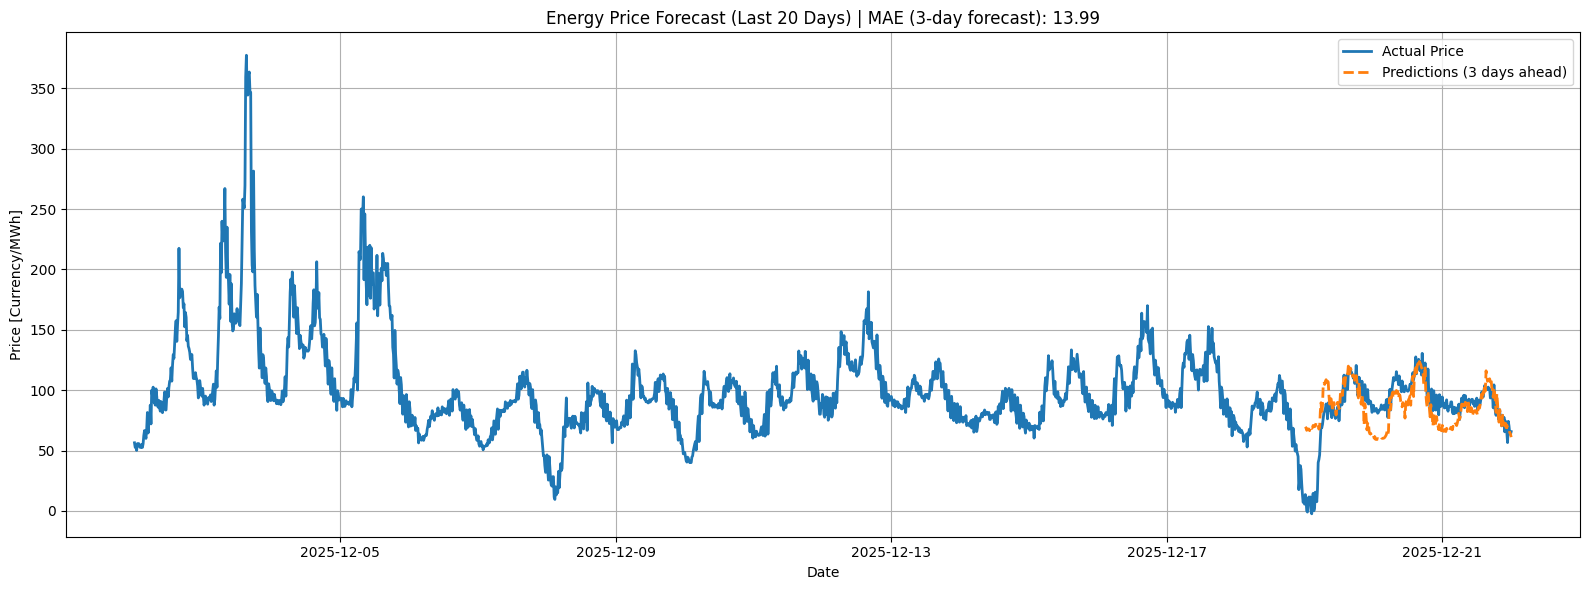

In [53]:
start_date = pd.to_datetime("2025-02-01 00:00:00", format="%Y-%m-%d %H:%M:%S")
end_date = pd.to_datetime("2025-12-22 00:00:00", format="%Y-%m-%d %H:%M:%S")
model_df["DateTime(UTC)"] =  pd.to_datetime(model_df["DateTime(UTC)"], format="%Y-%m-%d %H:%M:%S")
data_12m = model_df[(model_df["DateTime(UTC)"] >= start_date) & (model_df["DateTime(UTC)"] <= end_date)]


# ---------------------------
# 2. Define target + features
# ---------------------------

# Define target (3 days ahead = 288 steps)
target = 'target_288'

# Drop non-feature columns
drop_cols = ['DateTime(UTC)',
             'Price[Currency/MWh]',
             target,
             'date']
X = data_12m.drop(columns=drop_cols)
y = data_12m[target]

# ---------------------------
# 3. Train / Test split
# ---------------------------

# Last 3 days = 288 timesteps
forecast_horizon = 288

X_train = X.iloc[:-forecast_horizon]
y_train = y.iloc[:-forecast_horizon]

X_test = X.iloc[-forecast_horizon:]
y_test = y.iloc[-forecast_horizon:]

# ---------------------------
# 4. Train final model
# ---------------------------

best_params = random_search.best_params_

model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    **best_params
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
results = pd.DataFrame({
    "DateTime": data_12m['DateTime(UTC)'].iloc[-forecast_horizon:],
    "Actual_Price": data_12m['Price[Currency/MWh]'].iloc[-forecast_horizon:],
    "Predicted_Price": y_pred
})
results["DateTime_shifted"] = results["DateTime"] - pd.Timedelta(days=3)

# ---------------------------
# Compute MAE
# ---------------------------

mae = mean_absolute_error(results["Actual_Price"], results["Predicted_Price"])

# ---------------------------
# 7. Plot last 20 days
# ---------------------------

# 20 days = 20 * 96 timesteps
plot_horizon = 20 * 96

plot_data = data_12m.iloc[-plot_horizon:].copy()

plt.figure(figsize=(16, 6))

# Actual prices
plt.plot(
    plot_data['DateTime(UTC)'],
    plot_data['Price[Currency/MWh]'],
    label='Actual Price',
    linewidth=2
)

# Predictions (only last 3 days)
plt.plot(
    results['DateTime'],
    results['Predicted_Price'],
    label='Predictions (3 days ahead)',
    linestyle='--',
    linewidth=2
)

# Predictions (shifted)
# plt.plot(
#     results['DateTime_shifted'],
#     results['Predicted_Price'],
#     label='Predictions (made 3 days earlier)',
#     linestyle='--',
#     linewidth=2
# )

plt.title(f'Energy Price Forecast (Last 20 Days) | MAE (3-day forecast): {mae:.2f}')
plt.xlabel('Date')
plt.ylabel('Price [Currency/MWh]')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### beginning of December spikes (1st of December)

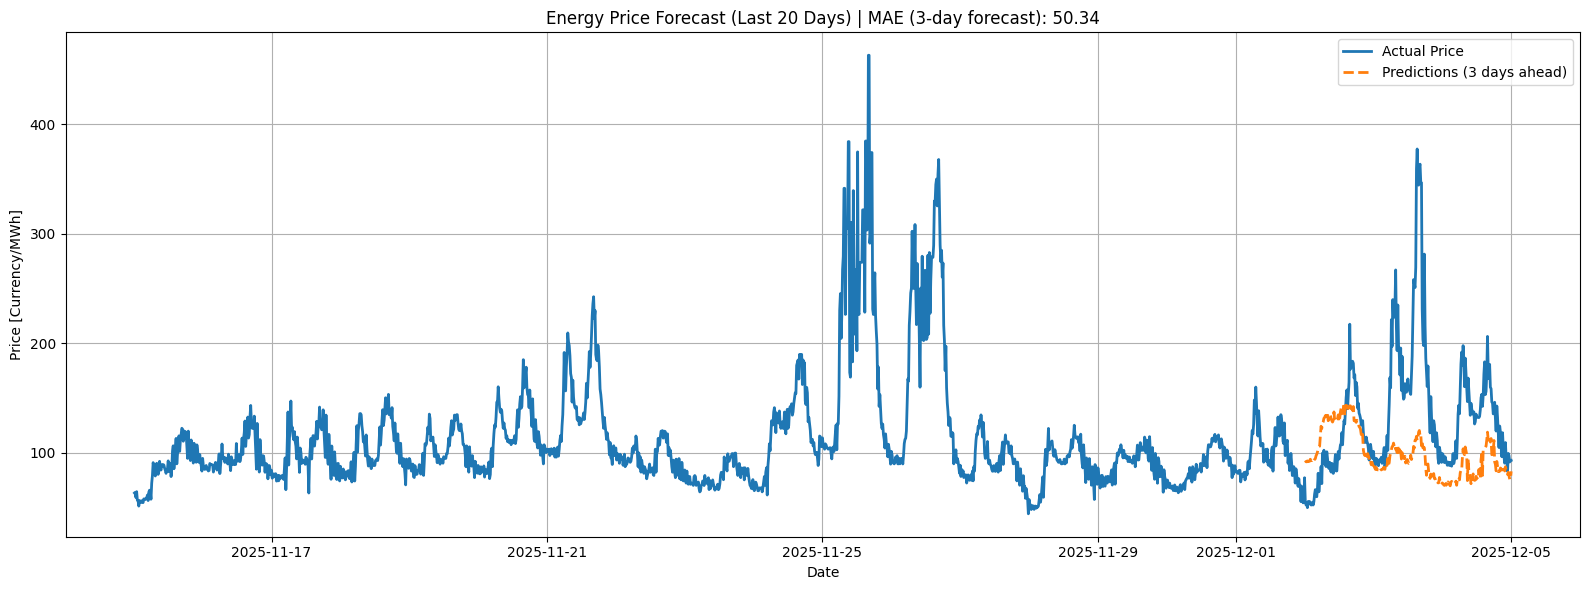

In [56]:
start_date = pd.to_datetime("2025-02-01 00:00:00", format="%Y-%m-%d %H:%M:%S")
end_date = pd.to_datetime("2025-12-05 00:00:00", format="%Y-%m-%d %H:%M:%S")
model_df["DateTime(UTC)"] =  pd.to_datetime(model_df["DateTime(UTC)"], format="%Y-%m-%d %H:%M:%S")
data_12m = model_df[(model_df["DateTime(UTC)"] >= start_date) & (model_df["DateTime(UTC)"] <= end_date)]


# ---------------------------
# 2. Define target + features
# ---------------------------

# Define target (3 days ahead = 288 steps)
target = 'target_288'

# Drop non-feature columns
drop_cols = ['DateTime(UTC)',
             'Price[Currency/MWh]',
             target,
             'date']
X = data_12m.drop(columns=drop_cols)
y = data_12m[target]

# ---------------------------
# 3. Train / Test split
# ---------------------------

# Last 3 days = 288 timesteps
forecast_horizon = 288

X_train = X.iloc[:-forecast_horizon]
y_train = y.iloc[:-forecast_horizon]

X_test = X.iloc[-forecast_horizon:]
y_test = y.iloc[-forecast_horizon:]

# ---------------------------
# 4. Train final model
# ---------------------------

best_params = random_search.best_params_

model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    **best_params
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
results = pd.DataFrame({
    "DateTime": data_12m['DateTime(UTC)'].iloc[-forecast_horizon:],
    "Actual_Price": data_12m['Price[Currency/MWh]'].iloc[-forecast_horizon:],
    "Predicted_Price": y_pred
})
results["DateTime_shifted"] = results["DateTime"] - pd.Timedelta(days=3)

# ---------------------------
# Compute MAE
# ---------------------------

mae = mean_absolute_error(results["Actual_Price"], results["Predicted_Price"])

# ---------------------------
# 7. Plot last 20 days
# ---------------------------

# 20 days = 20 * 96 timesteps
plot_horizon = 20 * 96

plot_data = data_12m.iloc[-plot_horizon:].copy()

plt.figure(figsize=(16, 6))

# Actual prices
plt.plot(
    plot_data['DateTime(UTC)'],
    plot_data['Price[Currency/MWh]'],
    label='Actual Price',
    linewidth=2
)

# Predictions (only last 3 days)
plt.plot(
    results['DateTime'],
    results['Predicted_Price'],
    label='Predictions (3 days ahead)',
    linestyle='--',
    linewidth=2
)

# Predictions (shifted)
# plt.plot(
#     results['DateTime_shifted'],
#     results['Predicted_Price'],
#     label='Predictions (made 3 days earlier)',
#     linestyle='--',
#     linewidth=2
# )

plt.title(f'Energy Price Forecast (Last 20 Days) | MAE (3-day forecast): {mae:.2f}')
plt.xlabel('Date')
plt.ylabel('Price [Currency/MWh]')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()